### Import Dependencies

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import mlflow
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
import json

In [27]:
data = pd.read_csv("..\Data\cleaned_data.csv", parse_dates=['date'])
data = data.sort_values('date')

In [45]:
data['date'].max()

Timestamp('2025-10-26 00:00:00')

In [46]:
data

,date,hospital_id,ward_code,wait_per_triage,age,bed_impact_score,arrival_source_ambulance,arrival_source_referral,arrival_source_self,arrival_source_transfer,...,overflow_lag1,overflow_lag7,discharges_lag1,discharges_lag7,admission_rate_per_bed_lag1,admission_rate_per_bed_lag7,avg_wait_minutes_lag1,avg_wait_minutes_lag7,occupancy_rate_lag1,occupancy_rate_lag7
0,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,...,42.0,26.0,33.0,33.0,2.233,1.867,227.0,227.0,1.000,1.0
355,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,...,37.0,39.0,32.0,32.0,2.167,2.233,226.0,276.0,1.000,1.0
354,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,...,29.0,42.0,30.0,33.0,1.833,2.233,233.0,296.0,1.000,1.0
353,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,...,42.0,38.0,30.0,32.0,2.233,2.200,299.0,286.0,1.000,1.0
352,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,...,41.0,26.0,27.0,31.0,2.133,1.767,299.0,166.0,1.000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19193,2025-10-26,1,ICU,31.666667,41.000000,29.250,1,2,5,0,...,1.0,5.0,12.0,3.0,0.325,0.325,89.0,130.0,0.935,1.0
19192,2025-10-26,1,ED,79.058333,57.416667,0.000,2,0,8,2,...,29.0,40.0,27.0,28.0,1.733,2.133,257.0,260.0,1.000,1.0
19207,2025-10-26,5,ICU,46.666667,61.333333,22.500,0,0,3,3,...,6.0,3.0,6.0,7.0,0.450,0.350,164.0,108.0,1.000,1.0
19199,2025-10-26,2,SURG,54.333333,55.000000,18.750,1,1,6,0,...,1.0,6.0,20.0,16.0,0.450,0.400,89.0,174.0,0.950,1.0


### Split the Data

In [22]:
train_size = int(len(data) * 0.8)

# train_data = data.iloc[:train_size]
# test_data = data.iloc[train_size:]

### Feature Selection with Mutual Info

In [5]:
mi_data = data.drop(columns=['date', 'hospital_id', 'ward_code'])

<Axes: ylabel='Feature'>

<Figure size 1000x800 with 0 Axes>

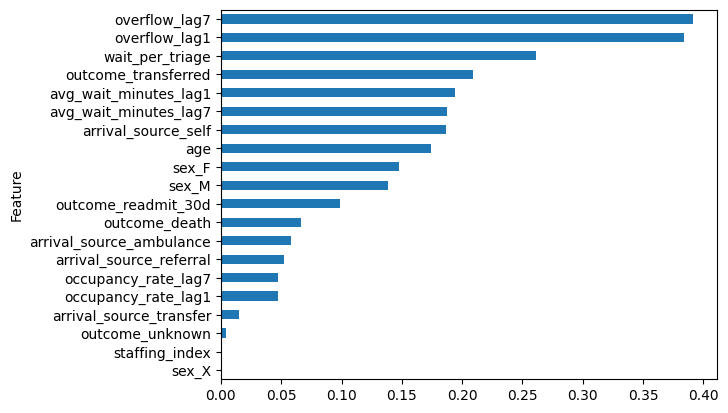

In [6]:
target = mi_data['admissions']
var = mi_data.drop(columns=['admissions'])

from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(var, target, random_state=42)
mi_df = pd.DataFrame(
    {
        'Feature': var.columns,
        'MI_Score': mi_scores
    }
).sort_values('MI_Score', ascending=True)

plt.figure(figsize=(10, 8))
mi_df.head(20).plot(x='Feature', y='MI_Score', kind='barh', legend=False)

### Split data with external features sampled on daily basis

In [20]:
top_features = mi_df['Feature'].head(20).to_list()

data = pd.get_dummies(data, columns=['ward_code'], drop_first=False)

bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

ward_cols = [col for col in data.columns if col.startswith('ward_code_')]

exog_features = top_features + ['hospital_id'] + ward_cols

print(train_size)

data = data.set_index('date')

X_train = data[exog_features].iloc[:train_size]
y_train = data['admissions'].iloc[:train_size]

X_test = data[exog_features].iloc[train_size:]
y_test = data['admissions'].iloc[train_size:]


KeyError: "None of [Index(['ward_code'], dtype='object')] are in the [columns]"

### Split data with external features sampled on weekly basis

In [9]:
data.columns

Index(['date', 'hospital_id', 'wait_per_triage', 'age', 'bed_impact_score',
       'arrival_source_ambulance', 'arrival_source_referral',
       'arrival_source_self', 'arrival_source_transfer', 'outcome_death',
       'outcome_discharged', 'outcome_readmit_30d', 'outcome_transferred',
       'outcome_unknown', 'sex_F', 'sex_M', 'sex_X', 'base_beds',
       'effective_capacity', 'admissions', 'staffing_index',
       'discharge_rate_per_bed', 'occupancy_lag1', 'occupancy_lag7',
       'overflow_lag1', 'overflow_lag7', 'discharges_lag1', 'discharges_lag7',
       'admission_rate_per_bed_lag1', 'admission_rate_per_bed_lag7',
       'avg_wait_minutes_lag1', 'avg_wait_minutes_lag7', 'occupancy_rate_lag1',
       'occupancy_rate_lag7', 'ward_code_ED', 'ward_code_ICU', 'ward_code_MED',
       'ward_code_SURCG', 'ward_code_SURG'],
      dtype='object')

In [25]:
print(train_size)

15367


In [28]:
top_features = mi_df['Feature'].head(20).to_list()

data = pd.get_dummies(data, columns=['ward_code'], drop_first=False)

bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

ward_cols = [col for col in data.columns if col.startswith('ward_code_')]

exog_features = top_features + ['hospital_id'] + ward_cols

data = data.set_index('date')



weekly_target = data['admissions'].resample('W').mean()
weekly_exog = data[exog_features].resample('W').mean()

train_size = int(len(weekly_target) * 0.8)

X_train = weekly_exog.iloc[:train_size]
y_train = weekly_target.iloc[:train_size]

X_test = weekly_exog.iloc[train_size:]
y_test = weekly_target.iloc[train_size:]

In [29]:
print(len(X_train), len(y_train), len(X_test), len(y_test))

125 125 32 32


### Train SARIMAX using MLFLOW

In [12]:
mlflow.set_experiment("Hospital Admissions Forecasting")

<Experiment: artifact_location='file:///c:/Users/HomePC/Downloads/medoptix-analytics/medOptix/model/mlruns/412456531948162918', creation_time=1764192919654, experiment_id='412456531948162918', last_update_time=1764192919654, lifecycle_stage='active', name='Hospital Admissions Forecasting', tags={}>

32
sarimax_mae: 0.4883821879406687
sarimax_rmse: 0.5928774594041234
sarimax_r2: 0.8666166914231725


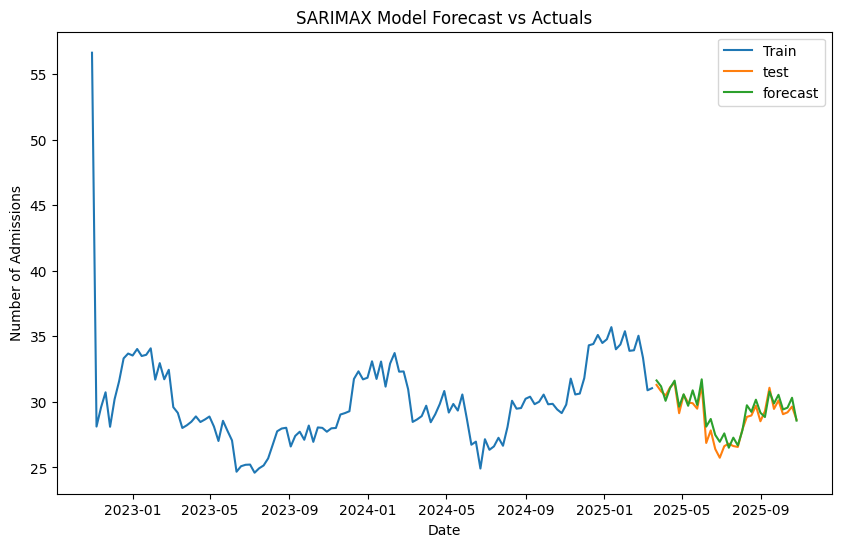

In [30]:
with mlflow.start_run(run_name="SARIMAX model"):
    sarimax_model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=(1, 1, 2),
        seasonal_order=(2, 0, 2, 7)
    ).fit(disp=False)

    print(len(y_test))

    sarimax_forecast = sarimax_model.forecast(steps=len(y_test), exog=X_test)

    sarimax_mae = mean_absolute_error(y_test, sarimax_forecast)
    sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_forecast))
    sarimax_r2 = r2_score(y_test, sarimax_forecast)

    print("sarimax_mae:", sarimax_mae)
    print("sarimax_rmse:", sarimax_rmse)
    print("sarimax_r2:", sarimax_r2)

    mlflow.log_param("order", (1, 1, 2))
    mlflow.log_param("seasonal_order", (2, 0, 2, 7))
    mlflow.log_param("exogenous_features", exog_features)

    mlflow.log_metric("MAE", sarimax_mae)
    mlflow.log_metric("RMSE", sarimax_rmse)
    mlflow.log_metric("R2_Score", sarimax_r2)

    with open("sarimax_model.pkl", "wb") as f:
        pickle.dump(sarimax_model, f)
    
    with open("sarimax_schema.json", "w") as f:
        json.dump(exog_features, f)

    mlflow.log_artifact("sarimax_model.pkl")

    plt.figure(figsize=(10, 6))
    plt.plot(y_train.index, y_train, label = 'Train')
    plt.plot(y_test.index, y_test, label ='test')
    plt.plot(y_test.index, sarimax_forecast, label = 'forecast')
    plt.legend()
    plt.title("SARIMAX Model Forecast vs Actuals")
    plt.xlabel("Date")
    plt.ylabel("Number of Admissions")
    plt.savefig("sarimax_forecast.png")

    mlflow.log_artifact("sarimax_forecast.png")
    plt.show()

### Hyper Parameter Tuning using Auto ARIMA

In [9]:
from pmdarima import auto_arima

model = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=7,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    
    stepwise=False, 
    random=True,  
    n_fits=30,   
    random_state=42 
)

print(model.summary())
print(f"Best order: {model.order}")
print(f"Best seasonal_order: {model.seasonal_order}")


 ARIMA(2,1,3)(0,0,0)[7] intercept   : AIC=127139.739, Time=37.18 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=148218.213, Time=0.44 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=127994.705, Time=35.25 sec
 ARIMA(0,1,2)(1,0,1)[7] intercept   : AIC=128692.666, Time=43.91 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=131430.344, Time=16.57 sec
 ARIMA(1,1,3)(0,0,1)[7] intercept   : AIC=127255.411, Time=36.02 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=131434.843, Time=22.62 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=129062.121, Time=9.55 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=147317.327, Time=11.23 sec
 ARIMA(2,1,1)(0,0,1)[7] intercept   : AIC=127993.547, Time=29.62 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=134067.257, Time=10.96 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=134068.729, Time=22.21 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=127396.818, Time=53.65 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=127318.973, Time=48.07 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   